# تشخیص هویت چهره با Eigenfaces و پیاده‌سازی PCA از صفر

در این پروژه می‌خواهیم PCA را با NumPy و بدون استفاده از PCA آماده پیاده‌سازی کنیم.

در این بخش تا محاسبه مقدارهای ویژه و ساخت Eigenfaceها پیش می‌رویم.

## گام ۱: دریافت و بررسی داده

برای دریافت دیتاست از sklearn استفاده می‌کنیم. محاسبات PCA را خودمان انجام می‌دهیم.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces()
images = faces.images
labels = faces.target

print(f"faces.images.shape: {faces.images.shape},\nfaces.data.shape: {faces.data.shape},\nfaces.target.shape: {faces.target.shape}")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\bayat\scikit_learn_data
faces.images.shape: (400, 64, 64),
faces.data.shape: (400, 4096),
faces.target.shape: (400,)


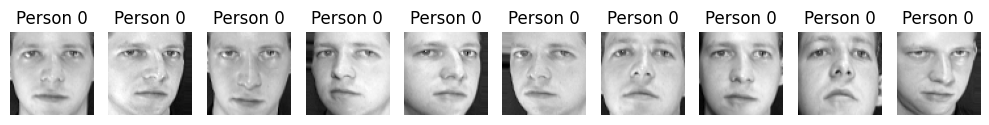

number of people: 40
images for each person: [10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10]


In [2]:
fig, axes = plt.subplots(1, 10, figsize=(10, 5))

for i in range(10):
    axes.flat[i].imshow(images[i], cmap='gray')
    axes.flat[i].set_title(f'Person {labels[i]}')
    axes.flat[i].axis('off')

plt.tight_layout()
plt.show()

print('number of people:', len(np.unique(labels)))
print('images for each person:', np.bincount(labels))

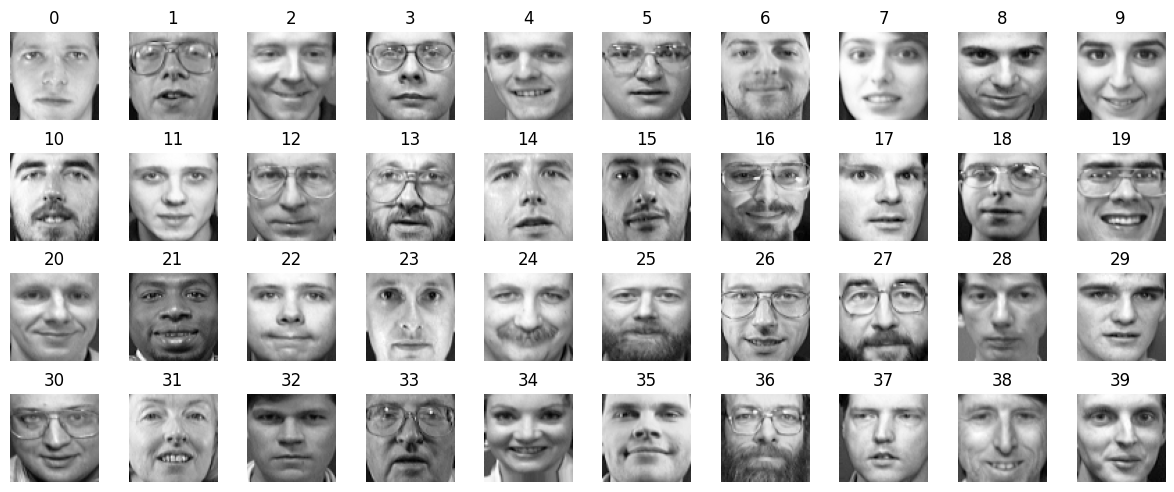

In [3]:
fig, axes = plt.subplots(4, 10, figsize=(12, 5))

for person in range(40):
    
    index = person * 10  
    
    ax = axes[person // 10, person % 10]
    
    ax.imshow(faces.images[index], cmap="gray")
    ax.axis("off")
    ax.set_title(f"{person}")

plt.tight_layout()
plt.show()

## گام ۲: جداسازی داده آموزش و آزمون

از هر شخص ۸ تصویر برای آموزش و ۲ تصویر برای آزمون انتخاب می‌کنیم.

عدد ۴۲ باعث می‌شود هر بار همان تقسیم قبلی را بگیریم.

In [4]:
rng = np.random.default_rng(42)

train_indices = []
test_indices = []

for person in np.unique(labels):
    person_indices = np.where(labels == person)[0]
    person_indices = rng.permutation(person_indices)

    train_indices.extend(person_indices[:8])
    test_indices.extend(person_indices[8:])

train_indices = np.array(train_indices)
test_indices = np.array(test_indices)

train_images = images[train_indices]
test_images = images[test_indices]
y_train = labels[train_indices]
y_test = labels[test_indices]

print('train images:', train_images.shape)
print('test images:', test_images.shape)

train images: (320, 64, 64)
test images: (80, 64, 64)


## گام ۳: تبدیل تصویر به بردار

هر تصویر ۶۴ در ۶۴ است. آن را به یک ردیف با ۴۰۹۶ عدد تبدیل می‌کنیم.

In [5]:
X_train = train_images.reshape(320, 4096).astype(np.float64)
X_test = test_images.reshape(80, 4096).astype(np.float64)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('8 train images for each person:', np.all(np.bincount(y_train) == 8))
print('2 test images for each person:', np.all(np.bincount(y_test) == 2))
print('train and test are separate:', len(np.intersect1d(train_indices, test_indices)) == 0)

X_train: (320, 4096)
X_test: (80, 4096)
8 train images for each person: True
2 test images for each person: True
train and test are separate: True


## گام ۴: محاسبه چهره میانگین و مرکزسازی

میانگین را فقط از داده آموزش حساب می‌کنیم. بعد همان میانگین را از آموزش و آزمون کم می‌کنیم.

```text
mean_face = sum of train images / number of train images
```

In [6]:
n_train = X_train.shape[0]

mean_face = np.sum(X_train, axis=0) / n_train

X_train_centered = X_train - mean_face
X_test_centered = X_test - mean_face

print(f"Shape of centered training data: {X_train_centered.shape}")
print(f"Shape of centered testing data: {X_test_centered.shape}")
print('mean after centering:', np.abs(X_train_centered.mean(axis=0)).max())

Shape of centered training data: (320, 4096)
Shape of centered testing data: (80, 4096)
mean after centering: 2.251671071817896e-16


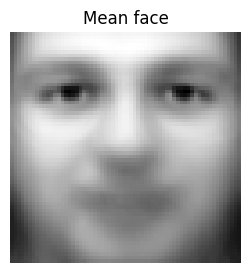

In [7]:
plt.figure(figsize=(3, 3))
plt.imshow(mean_face.reshape(64, 64), cmap='gray')
plt.title('Mean face')
plt.axis('off')
plt.show()

## گام ۵: پیاده‌سازی PCA از صفر

واریانس و کوواریانس را مستقیماً از تصویرهای train مرکز‌شده بررسی می‌کنیم. برای سبک‌ترشدن محاسبه، به‌جای covariance بزرگ پیکسل‌ها از Gram matrix استفاده می‌کنیم. توضیح کامل این انتخاب در [راهنمای آموزشی](docs/LEARNING_GUIDE.md) آمده است.

### ۵.۱ ساخت ماتریس Gram از داده‌های واقعی

ماتریس کوواریانس پیکسل‌ها ۴۰۹۶ در ۴۰۹۶ می‌شود. برای اینکه محاسبه سبک‌تر باشد، ماتریس Gram را می‌سازیم که ۳۲۰ در ۳۲۰ است.

```text
Gram = (X_centered @ X_centered.T) / (n - 1)
```

In [8]:
gram_matrix = (X_train_centered @ X_train_centered.T) / (n_train - 1)
total_variance = np.sum(X_train_centered ** 2) / (n_train - 1)

print('Gram matrix shape:', gram_matrix.shape)
print('symmetric:', np.allclose(gram_matrix, gram_matrix.T))

Gram matrix shape: (320, 320)
symmetric: True


### ۵.۲ محاسبه مقدارهای ویژه و بردارهای ویژه

از `eigh` استفاده می‌کنیم چون ماتریس Gram متقارن است. این تابع مقدارها را از کوچک به بزرگ می‌دهد، پس آن‌ها را برعکس می‌کنیم.

In [9]:
eigenvalues, eigenvectors = np.linalg.eigh(gram_matrix)

order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

useful = eigenvalues > eigenvalues[0] * 1e-10
eigenvalues = eigenvalues[useful]
eigenvectors = eigenvectors[:, useful]

print('number of eigenvalues:', len(eigenvalues))
print('first 10 eigenvalues:')
print(np.round(eigenvalues[:10], 4))

number of eigenvalues: 319
first 10 eigenvalues:
[18.9296 11.6741  6.1354  3.8166  2.8252  2.5447  1.9134  1.6315  1.6082
  1.303 ]


## گام ۶: ساخت و نمایش Eigenfaceها

بردارهای ویژه فعلی ۳۲۰ عدد دارند. آن‌ها را به فضای ۴۰۹۶ پیکسلی برمی‌گردانیم و طول هر بردار را یک می‌کنیم.

In [10]:
eigenfaces = X_train_centered.T @ eigenvectors

lengths = np.sqrt(np.sum(eigenfaces ** 2, axis=0))
eigenfaces = eigenfaces / lengths

print('eigenfaces shape:', eigenfaces.shape)

eigenfaces shape: (4096, 319)


In [11]:
print(f"The shape of the each of the vector: {eigenfaces[:, 0].shape}")
print(f"The eigenfaces shape: {eigenfaces.shape}")

The shape of the each of the vector: (4096,)
The eigenfaces shape: (4096, 319)


In [12]:
center_is_ok = np.allclose(X_train_centered.mean(axis=0), 0, atol=1e-12)
values_are_sorted = np.all(np.diff(eigenvalues) <= 0)
variance_is_preserved = np.allclose(np.sum(eigenvalues), total_variance)

identity = np.eye(eigenfaces.shape[1])
vectors_are_orthogonal = np.allclose(
    eigenfaces.T @ eigenfaces, identity, atol=1e-10
)

print('centering is correct:', center_is_ok)
print('eigenvalues are sorted:', values_are_sorted)
print('eigenfaces are orthonormal:', vectors_are_orthogonal)
print('total variance:', round(total_variance, 4))
print('sum of eigenvalues:', round(np.sum(eigenvalues), 4))
print('variance is preserved:', variance_is_preserved)

centering is correct: True
eigenvalues are sorted: True
eigenfaces are orthonormal: True
total variance: 79.4179
sum of eigenvalues: 79.4179
variance is preserved: True


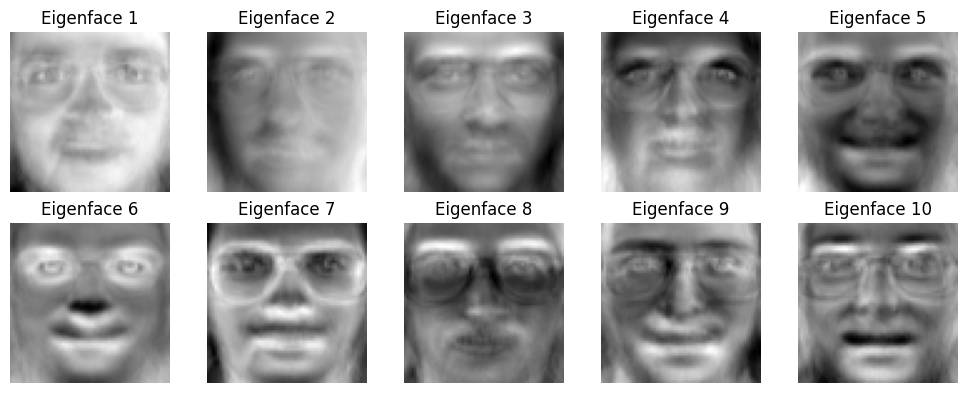

variance of first component: 23.84 %
variance of first 10 components: 65.96 %


In [13]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i in range(10):
    axes.flat[i].imshow(eigenfaces[:, i].reshape(64, 64), cmap='gray')
    axes.flat[i].set_title(f'Eigenface {i + 1}')
    axes.flat[i].axis('off')

plt.tight_layout()
plt.show()

variance_ratio = eigenvalues / np.sum(eigenvalues)
print('variance of first component:', round(variance_ratio[0] * 100, 2), '%')
print('variance of first 10 components:', round(np.sum(variance_ratio[:10]) * 100, 2), '%')

## پایان بخش‌های تکمیل‌شده

تا اینجا داده را جدا و مرکز کردیم، ماتریس Gram را ساختیم و Eigenfaceها را به دست آوردیم.

در بخش بعدی تصویرها را روی این بردارها می‌اندازیم و بازسازی و تشخیص هویت را انجام می‌دهیم.

## گام ۷: Projection و Reconstruction

در این بخش تصویرهای train و test را به فضای کم‌بعد می‌بریم و برای `k = 10, 50, 150` بازسازی می‌کنیم.

In [14]:
ks = [10, 50, 150]

train_codes = {}
test_codes = {}
test_reconstructions = {}
test_mse = {}

for k in ks:
    U_k = eigenfaces[:, :k]

    train_codes[k] = X_train_centered @ U_k
    test_codes[k] = X_test_centered @ U_k
    test_reconstructions[k] = test_codes[k] @ U_k.T + mean_face
    test_mse[k] = np.mean((X_test - test_reconstructions[k]) ** 2)

    assert train_codes[k].shape == (X_train.shape[0], k)
    assert test_codes[k].shape == (X_test.shape[0], k)
    assert test_reconstructions[k].shape == X_test.shape

print(' k | train codes | test codes | test MSE')
print('-' * 51)
for k in ks:
    print(
        f'{k:3d} | {str(train_codes[k].shape):>11} | '
        f'{str(test_codes[k].shape):>10} | {test_mse[k]:.8f}'
    )

 k | train codes | test codes | test MSE
---------------------------------------------------
 10 |   (320, 10) |   (80, 10) | 0.00706589
 50 |   (320, 50) |   (80, 50) | 0.00326911
150 |  (320, 150) |  (80, 150) | 0.00205541


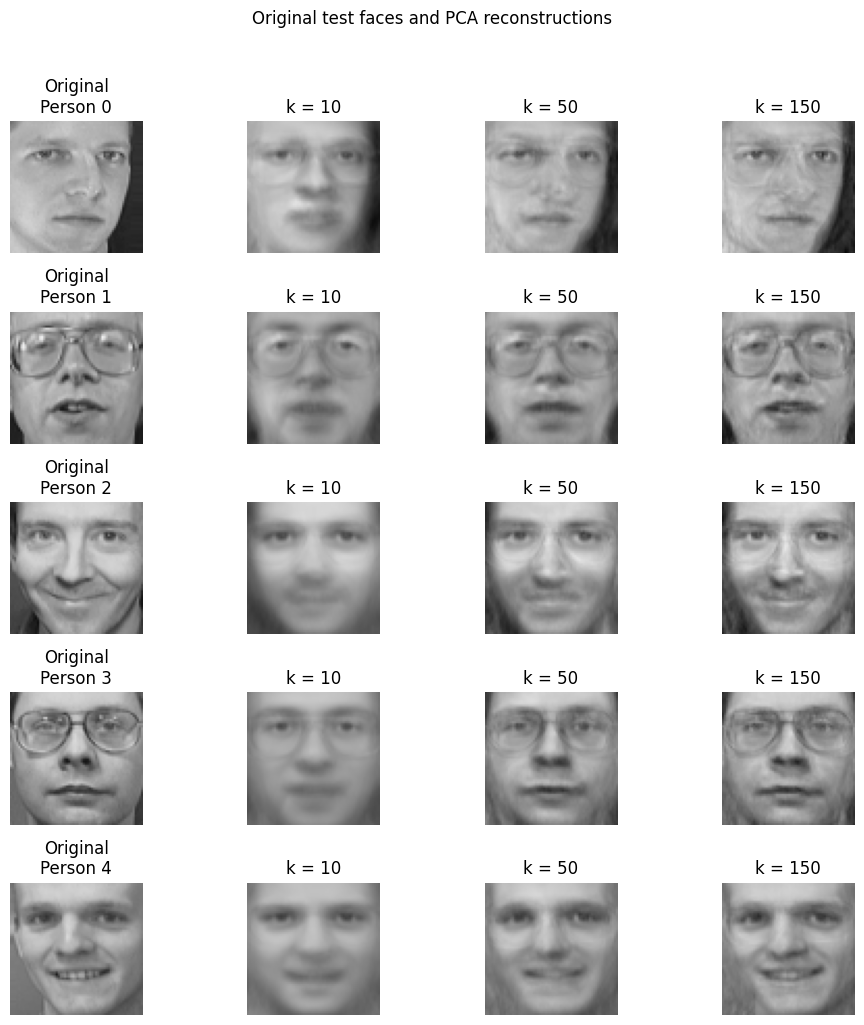

In [15]:

sample_indices = [0, 2, 4, 6, 8]

fig, axes = plt.subplots(5, 4, figsize=(10, 10))

for row, test_index in enumerate(sample_indices):
    original_image = X_test[test_index]
    axes[row, 0].imshow(
        original_image.reshape(64, 64),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 0].set_title(f"Original\nPerson {y_test[test_index]}")
    axes[row, 0].axis("off")

    for column, k in enumerate(ks):
        reconstructed_image = test_reconstructions[k][test_index]

        axes[row, column + 1].imshow(
            reconstructed_image.reshape(64, 64),
            cmap="gray",
            vmin=0,
            vmax=1
        )
        axes[row, column + 1].set_title(f"k = {k}")
        axes[row, column + 1].axis("off")

fig.suptitle('Original test faces and PCA reconstructions', y=1.02)
plt.tight_layout()
plt.show()

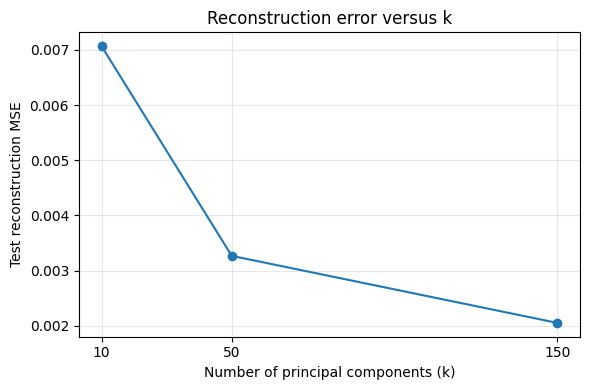

MSE is non-increasing as k grows: True


In [16]:
mse_values = np.array([test_mse[k] for k in ks])

assert np.all(np.diff(mse_values) <= 1e-12)

plt.figure(figsize=(6, 4))
plt.plot(ks, mse_values, marker='o')
plt.xlabel('Number of principal components (k)')
plt.ylabel('Test reconstruction MSE')
plt.title('Reconstruction error versus k')
plt.grid(alpha=0.3)
plt.xticks(ks)
plt.tight_layout()
plt.show()

print('MSE is non-increasing as k grows:', np.all(np.diff(mse_values) <= 1e-12))

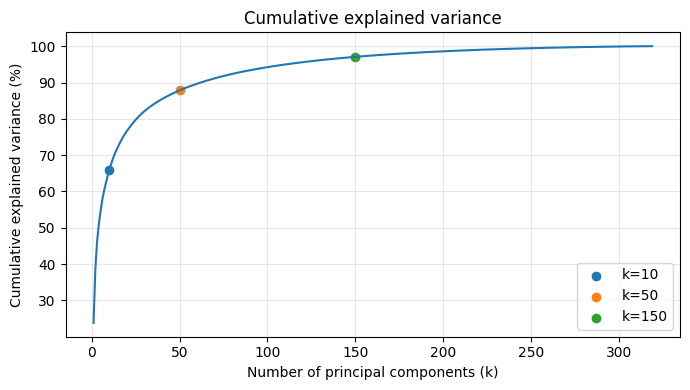

k= 10: 65.96% variance preserved
k= 50: 87.85% variance preserved
k=150: 97.06% variance preserved


In [17]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)
component_numbers = np.arange(1, len(cumulative_variance) + 1)

plt.figure(figsize=(7, 4))
plt.plot(component_numbers, cumulative_variance * 100)
for k in ks:
    plt.scatter(k, cumulative_variance[k - 1] * 100, label=f'k={k}')
plt.xlabel('Number of principal components (k)')
plt.ylabel('Cumulative explained variance (%)')
plt.title('Cumulative explained variance')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for k in ks:
    print(f'k={k:3d}: {cumulative_variance[k - 1] * 100:.2f}% variance preserved')

## گام ۸: ارزیابی بازسازی و تشخیص هویت

در این بخش reconstruction error، نزدیک‌ترین همسایه، accuracy و نمونه‌های موفق و شکست را بررسی می‌کنیم.

## گام ۹: مقایسه حداقلی با SVD

در این بخش نتیجه مسیر eigendecomposition را با `numpy.linalg.svd` کنترل می‌کنیم.

## مأموریت اختصاصی تیم ۴: Euclidean در برابر Cosine

در این بخش دو معیار را با داده، مؤلفه‌ها و مقدار `k` یکسان مقایسه می‌کنیم.

## دموی تعاملی

در این بخش با انتخاب تصویر test، مقدار `k` و معیار شباهت، بازسازی و نزدیک‌ترین تصویر train را نمایش می‌دهیم.

## جمع‌بندی و محدودیت‌ها

در پایان به سؤال اصلی و سؤال تیم ۴ پاسخ می‌دهیم و محدودیت‌های واقعی آزمایش را می‌نویسیم.